In [ ]:
!pip install ftfy regex tqdm torchmetrics
!pip install git+https://github.com/openai/CLIP.git
!pip install transformers

In [2]:
from google.colab import drive
drive.mount('drive')

Mounted at drive


In [3]:
import clip

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import BlipProcessor, BlipForConditionalGeneration

import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 0

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print("Device:", DEVICE)

Device: cuda


In [4]:
model, preprocess = clip.load('ViT-L/14', DEVICE, jit=False)
model.eval()
for p in model.parameters():
    p.requires_grad = False

print("CLIP caricato, feature dim:", model.visual.output_dim) # model.visual = ramo visivo di CLIP, che trasforma immagini in vettori di 768 elementi

100%|███████████████████████████████████████| 890M/890M [00:13<00:00, 69.6MiB/s]


CLIP caricato, feature dim: 768


In [5]:
import os
import pandas as pd

from sklearn.model_selection import train_test_split
from PIL import Image
from torch.utils.data import Dataset


class AMLDataset(Dataset):
    def __init__(self, csv_path, imgs_dir, train=True, transform=None):
        self.imgs_dir = imgs_dir
        self.train = train
        self.transform = transform

        full_df = pd.read_csv(csv_path)

        train_df, test_df = train_test_split(
            full_df,
            test_size=0.20,            # 20% for validation
            random_state=42,
            stratify=full_df['label']  # Ensures all 250 classes are in both
        )

        train_df = full_df

        self.df = (train_df if train else test_df).reset_index(drop=True)

        # Create the 'classes' attribute (Unique list of names)
        # We sort them to ensure the index mapping is always consistent
        self.classes = sorted(self.df['label'].unique().tolist())

        # Create a mapping from Name -> Integer ID
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        # Create the 'labels' attribute (The ID for every single row)
        # This is helpful if you want to use a Weighted or Balanced Sampler later
        self.labels = [self.class_to_idx[name] for name in self.df['label']]


    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self._load_img(row['filename'])
        return img, self.labels[idx]

    def _load_img(self, filename):
        path = os.path.join(self.imgs_dir, str(filename))
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

In [6]:
class AMLValidation(Dataset):
    def __init__(self, csv_path, imgs_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.imgs_dir = imgs_dir
        self.transform = transform

        # Group the rows by episode_id so __len__ returns total number of tasks
        self.episode_ids = sorted(self.df['episode_id'].unique())

    def __len__(self):
        return len(self.episode_ids)

    def load_img(self, filename):
        img_path = os.path.join(self.imgs_dir, str(filename))
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)
        return img

    def _load_img(self, filename):
        path = os.path.join(self.imgs_dir, str(filename))
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

    def __getitem__(self, idx):
        # Return a full 5-way 5-shot Episode
        ep_id = self.episode_ids[idx]
        ep_df = self.df[self.df['episode_id'] == ep_id]

        support_df = ep_df[ep_df['role'] == 'support']
        query_df = ep_df[ep_df['role'] == 'query']

        # Pack support images and their labels
        s_imgs = [f"{self.imgs_dir}/{f}" for f in support_df['filename']]
        s_labels = support_df['label'].values

        # Pack query images
        q_imgs = [f"{self.imgs_dir}/{f}" for f in query_df['filename']]

        return {
            "support_imgs": s_imgs,
            "support_labels": s_labels,
            "query_imgs": q_imgs,
            "episode_id": ep_id
        }

        # Pack support images and their labels
        s_imgs = torch.stack([self._load_img(f) for f in support_df['filename']])
        s_labels = torch.tensor(support_df['label'].values)

        # Pack query images
        q_imgs = torch.stack([self.load_img(f) for f in query_df['filename']])

        # If your test CSV has query labels (sometimes they are hidden), include them:
        # q_labels = torch.tensor(query_df['label'].values) if 'label' in query_df.columns else None

        return {
            "support_imgs": s_imgs,
            "support_labels": s_labels,
            "query_imgs": q_imgs,
            "episode_id": ep_id
        }

In [7]:
CSV_PATH = "drive/MyDrive/AdvancedML/Project/release/train.csv"
IMGS_DIR = "drive/MyDrive/AdvancedML/Project/release/images/"
VAL_CSV  = "drive/MyDrive/AdvancedML/Project/release/test_episodes_release.csv"

train_dataset = AMLDataset(csv_path=CSV_PATH, imgs_dir=IMGS_DIR, train=True,  transform=preprocess)
test_dataset  = AMLDataset(csv_path=CSV_PATH, imgs_dir=IMGS_DIR, train=False, transform=preprocess)
val_dataset   = AMLValidation(csv_path=VAL_CSV, imgs_dir=IMGS_DIR)  # senza preprocess — le immagini le carichiamo a mano

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  drop_last=True, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, drop_last=True, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=1,  shuffle=False, drop_last=True)

print("Classi:", len(train_dataset.classes))
print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Classi: 250
Train samples: 5000
Test samples: 1000


In [8]:
from transformers import BlipProcessor, BlipForConditionalGeneration

print("Caricando BLIP...")
blip_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(DEVICE)
blip_model.eval()
for p in blip_model.parameters():
    p.requires_grad = False

print("BLIP pronto!")

Caricando BLIP...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

BLIP pronto!


Classe: 354
Caption: a water tower in a rural setting


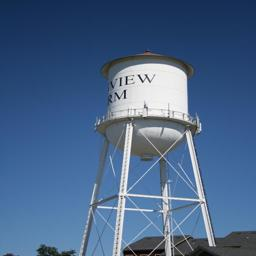

In [9]:
sample_row = train_dataset.df.iloc[0]
sample_path = os.path.join(train_dataset.imgs_dir, str(sample_row['filename']))
sample_label = sample_row['label']

pil_img = Image.open(sample_path).convert("RGB")

inputs = blip_processor(pil_img, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    out = blip_model.generate(**inputs, max_new_tokens=40)
caption = blip_processor.decode(out[0], skip_special_tokens=True)

print(f"Classe: {sample_label}")
print(f"Caption: {caption}")
pil_img

In [12]:
# Testa su 5 classi diverse
sample_classes = train_dataset.classes[:5]

for class_id in sample_classes:
    # Prendi il primo indice di questa classe
    idx = train_dataset.labels.index(
        train_dataset.class_to_idx[class_id]
    )
    row = train_dataset.df.iloc[idx]
    path = os.path.join(train_dataset.imgs_dir, str(row['filename']))

    pil_img = Image.open(path).convert("RGB")
    inputs = blip_processor(pil_img, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        out = blip_model.generate(**inputs, max_new_tokens=40)
    caption = blip_processor.decode(out[0], skip_special_tokens=True)

    print(f"Classe {class_id:3d} → {caption}")

Classe   0 → a large blue and white plane
Classe   1 → a group of people standing in front of a plane
Classe   2 → a gym with a lot of equipment
Classe   4 → a sign on a building
Classe   5 → two people walking down a street in the ruins


In [13]:
@torch.no_grad()
def peft_encode_images(clip_model, images):
    image_features = clip_model.encode_image(images).float()
    return F.normalize(image_features, dim=-1)

@torch.no_grad()
def peft_encode_text_tokens(clip_model, tokens):
    text_features = clip_model.encode_text(tokens).float()
    return F.normalize(text_features, dim=-1)

def accuracy_from_logits(logits, labels):
    predictions = logits.argmax(dim=1)
    return (predictions == labels).float().mean().item() * 100

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

In [15]:
@torch.no_grad()
def build_blip_text_features(train_dataset, clip_model, blip_model, blip_processor,
                              images_per_class=5):
    """
    Per ogni classe:
      - prende images_per_class immagini
      - genera caption con BLIP
      - codifica le caption con CLIP text encoder
      - fa la media → 1 vettore per classe
    Ritorna: [num_classes, 768]
    """
    # Mappa class_idx → indici nel dataset
    class_to_indices = {}
    for idx, label in enumerate(train_dataset.labels):
        class_to_indices.setdefault(label, []).append(idx)

    all_text_features = []

    for class_idx in tqdm(range(len(train_dataset.classes)), desc="BLIP captioning"):
        indices = class_to_indices[class_idx][:images_per_class]
        captions = []

        for i in indices:
            row = train_dataset.df.iloc[i]
            path = os.path.join(train_dataset.imgs_dir, str(row['filename']))
            pil_img = Image.open(path).convert("RGB")

            inputs = blip_processor(pil_img, return_tensors="pt").to(DEVICE)
            out = blip_model.generate(**inputs, max_new_tokens=40)
            caption = blip_processor.decode(out[0], skip_special_tokens=True)
            captions.append(caption)

        # Codifica le caption con CLIP
        tokens = clip.tokenize(captions, truncate=True).to(DEVICE)
        features = peft_encode_text_tokens(clip_model, tokens)  # [K, 768]
        class_feature = F.normalize(features.mean(dim=0), dim=-1)
        all_text_features.append(class_feature)

    return torch.stack(all_text_features)  # [250, 768]


# Lancia — ~5-10 minuti su GPU
blip_text_features = build_blip_text_features(
    train_dataset, model, blip_model, blip_processor,
    images_per_class=5
)

# Salva subito su Drive
torch.save(blip_text_features.cpu(),
           "drive/MyDrive/AdvancedML/Project/blip_text_features.pt")

print("Shape:", blip_text_features.shape)  # [250, 768]
print("Salvato!")

BLIP captioning:   0%|          | 0/250 [00:00<?, ?it/s]

Shape: torch.Size([250, 768])
Salvato!


In [16]:
@torch.no_grad()
def extract_clip_feature_dataset(clip_model, loader):
    all_features, all_labels = [], []
    for images, labels in tqdm(loader, desc="extract frozen CLIP features", leave=False):
        images = images.to(DEVICE)
        features = peft_encode_images(clip_model, images)
        all_features.append(features.cpu())
        all_labels.append(labels.cpu())
    return torch.cat(all_features, dim=0), torch.cat(all_labels, dim=0)

peft_train_features, peft_train_labels = extract_clip_feature_dataset(model, train_loader)
peft_test_features, peft_test_labels   = extract_clip_feature_dataset(model, test_loader)

peft_feature_dim  = peft_train_features.shape[1]
peft_num_classes  = len(train_dataset.classes)

print("Train features:", peft_train_features.shape)
print("Test features: ", peft_test_features.shape)
print("Feature dim:   ", peft_feature_dim)
print("Num classes:   ", peft_num_classes)

extract frozen CLIP features:   0%|          | 0/156 [00:00<?, ?it/s]

extract frozen CLIP features:   0%|          | 0/31 [00:00<?, ?it/s]

Train features: torch.Size([4992, 768])
Test features:  torch.Size([992, 768])
Feature dim:    768
Num classes:    250


In [16]:
torch.save({
    'peft_train_features': peft_train_features,
    'peft_train_labels':   peft_train_labels,
    'peft_test_features':  peft_test_features,
    'peft_test_labels':    peft_test_labels,
    'peft_feature_dim':    peft_feature_dim,
    'peft_num_classes':    peft_num_classes,
}, "drive/MyDrive/AdvancedML/Project/clip_features.pt")
print("Salvato!")

In [19]:
@torch.no_grad()
def build_blip_text_features_v2(train_dataset, clip_model, blip_model, blip_processor,
                                  images_per_class=10):
    class_to_indices = {}
    for idx, label in enumerate(train_dataset.labels):
        class_to_indices.setdefault(label, []).append(idx)

    all_text_features = []

    for class_idx in tqdm(range(len(train_dataset.classes)), desc="BLIP captioning v2"):
        indices = class_to_indices[class_idx][:images_per_class]
        captions = []

        for i in indices:
            row = train_dataset.df.iloc[i]
            path = os.path.join(train_dataset.imgs_dir, str(row['filename']))
            pil_img = Image.open(path).convert("RGB")
            inputs = blip_processor(pil_img, return_tensors="pt").to(DEVICE)
            out = blip_model.generate(**inputs, max_new_tokens=40)
            caption = blip_processor.decode(out[0], skip_special_tokens=True)

            # Filtra caption in loop — parola ripetuta 3+ volte di fila
            words = caption.split()
            is_loop = any(
                words[j] == words[j+1] == words[j+2]
                for j in range(len(words)-2)
            ) if len(words) >= 3 else False

            if not is_loop:
                captions.append(caption)

        # Se tutte le caption sono state filtrate usa fallback generico
        if len(captions) == 0:
            captions = ["a photo of an object"]

        tokens = clip.tokenize(captions, truncate=True).to(DEVICE)
        features = peft_encode_text_tokens(clip_model, tokens)  # [K, 768]
        class_feature = F.normalize(features.mean(dim=0), dim=-1)
        all_text_features.append(class_feature)

    return torch.stack(all_text_features)  # [250, 768]


blip_text_features_v2 = build_blip_text_features_v2(
    train_dataset, model, blip_model, blip_processor,
    images_per_class=10
)

torch.save(blip_text_features_v2.cpu(),
           "drive/MyDrive/AdvancedML/Project/blip_text_features_v2.pt")

# Verifica zero-shot
with torch.no_grad():
    zs_logits = 100.0 * peft_test_features.to(DEVICE) @ blip_text_features_v2.to(DEVICE).T
    zs_acc = accuracy_from_logits(zs_logits, peft_test_labels.to(DEVICE))

print(f"Zero-shot v2: {zs_acc:.2f}%")

BLIP captioning v2:   0%|          | 0/250 [00:00<?, ?it/s]

Zero-shot v2: 46.88%


In [20]:
import copy

def train_on_cached_features(model, train_features, train_labels, test_features, test_labels,
                              epochs=20, lr=1e-3, batch_size=256, name="feature-model", patience=10):
    model = model.to(DEVICE)
    trainable_parameters = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_parameters, lr=lr, weight_decay=0.1)
    loss_fn = nn.CrossEntropyLoss()

    train_features = train_features.to(DEVICE)
    train_labels   = train_labels.to(DEVICE)
    test_features  = test_features.to(DEVICE)
    test_labels    = test_labels.to(DEVICE)

    best_acc     = 0.0
    best_weights = None
    no_improve   = 0
    n = train_features.shape[0]

    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(n, device=DEVICE)
        total_loss  = 0.0

        for start in range(0, n, batch_size):
            indices = permutation[start:start + batch_size]
            logits  = model(train_features[indices])
            loss    = loss_fn(logits, train_labels[indices])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * indices.numel()

        model.eval()
        with torch.no_grad():
            accuracy = accuracy_from_logits(model(test_features), test_labels)

        print(f"{name} | epoch {epoch+1:03d}/{epochs} | loss {total_loss/n:.4f} | acc {accuracy:.2f}%")

        if accuracy > best_acc:
            best_acc     = accuracy
            best_weights = copy.deepcopy(model.state_dict())
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping a epoch {epoch+1} — best acc: {best_acc:.2f}%")
                break

    model.load_state_dict(best_weights)
    return best_acc


class FeatureLinearProbe(nn.Module):
    def __init__(self, feature_dim, num_classes):
        super().__init__()
        self.classifier = nn.Linear(feature_dim, num_classes, bias=False)

    def forward(self, image_features):
        return self.classifier(image_features)

In [ ]:
linear_probe = FeatureLinearProbe(peft_feature_dim, peft_num_classes).to(DEVICE)

linear_accuracy = train_on_cached_features(
    linear_probe,
    peft_train_features,
    peft_train_labels,
    peft_test_features,
    peft_test_labels,
    epochs=1000,
    lr=1e-3,
    batch_size=256,
    patience=20,
    name="Linear probe",
)
print(f"Accuracy finale: {linear_accuracy:.2f}%")

In [22]:
torch.save(linear_probe.cpu().state_dict(),
           "drive/MyDrive/AdvancedML/Project/linear_probe.pt")
linear_probe = linear_probe.to(DEVICE)
print("Probe salvato!")

Probe salvato!


In [14]:
@torch.no_grad()
def run_blip_episodic_validation(val_loader, clip_model, blip_model,
                                  blip_processor, preprocess):
    clip_model.eval()
    blip_model.eval()
    all_predictions = []
    query_id = 0

    for batch in tqdm(val_loader, desc="[BLIP episodic]"):
        s_imgs_paths = [p[0] for p in batch['support_imgs']]
        s_labels_raw = batch['support_labels'].squeeze(0).long()
        q_imgs_paths = [p[0] for p in batch['query_imgs']]

        unique_labels = torch.unique(s_labels_raw)

        # 1. Text prototypes da BLIP per ogni classe
        text_prototypes = []
        for class_label in unique_labels:
            mask = (s_labels_raw == class_label)
            class_img_paths = [s_imgs_paths[i] for i, m in enumerate(mask) if m]

            captions = []
            for path in class_img_paths:
                pil_img = Image.open(path).convert("RGB")
                inputs  = blip_processor(pil_img, return_tensors="pt").to(DEVICE)
                out     = blip_model.generate(**inputs, max_new_tokens=40)
                caption = blip_processor.decode(out[0], skip_special_tokens=True)

                words   = caption.split()
                is_loop = any(
                    words[j] == words[j+1] == words[j+2]
                    for j in range(len(words)-2)
                ) if len(words) >= 3 else False

                if not is_loop:
                    captions.append(caption)

            if len(captions) == 0:
                captions = ["a photo of an object"]

            tokens    = clip.tokenize(captions, truncate=True).to(DEVICE)
            features  = peft_encode_text_tokens(clip_model, tokens)
            prototype = F.normalize(features.mean(dim=0), dim=-1)
            text_prototypes.append(prototype)

        text_prototypes = torch.stack(text_prototypes)  # [5, 768]

        # 2. Encode query con CLIP
        q_tensors  = torch.stack([preprocess(Image.open(p)) for p in q_imgs_paths]).to(DEVICE)
        q_features = peft_encode_images(clip_model, q_tensors)

        # 3. Cosine similarity
        logits       = 100.0 * (q_features @ text_prototypes.T)
        pred_indices = logits.argmax(dim=-1)
        predicted_class_ids = [unique_labels[i.item()].item() for i in pred_indices]

        for pred in predicted_class_ids:
            all_predictions.append({"Id": query_id, "label": pred})
            query_id += 1

    return all_predictions

In [15]:
predictions = run_blip_episodic_validation(
    val_loader, model, blip_model, blip_processor, preprocess
)

pd.DataFrame(predictions).to_csv("group_3_blip_episodic.csv", index=False)
print(f"Salvato! Totale predizioni: {len(predictions)}")

[BLIP episodic]:   0%|          | 0/20 [00:00<?, ?it/s]

Salvato! Totale predizioni: 500


In [16]:
df = pd.read_csv("group_3_blip_episodic.csv")
print(df.head(10))
print("\nShape:", df.shape)
print("Colonne:", df.columns.tolist())
print("Id min:", df['Id'].min(), "Id max:", df['Id'].max())
print("Id unici:", df['Id'].nunique())

   Id  label
0   0    204
1   1    204
2   2    204
3   3    204
4   4    166
5   5    166
6   6    166
7   7    300
8   8    300
9   9    295

Shape: (500, 2)
Colonne: ['Id', 'label']
Id min: 0 Id max: 499
Id unici: 500
